In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import spCLUE
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

spCLUE.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [2]:
import scanpy as sc
import pandas as pd
import os

# 1. 设置路径
data_dir = '/home/pxy/home/pxy/data/Human_Breast_Cancer/'
# 根据 spCLUE 论文，该数据集包含 20 个标注区域 [cite: 205, 691]
n_clusters = 20 

# 2. 加载数据
# sc.read_visium 会自动读取该目录下的 .h5 文件和 spatial 文件夹
adata = sc.read_visium(data_dir)
adata.var_names_make_unique()

# 3. 加载元数据并对齐
meta = pd.read_csv(os.path.join(data_dir, "metadata.tsv"), sep="\t")

# 【核心修正】：将索引设置为 "ID" 而不是 "barcode"
meta = meta.set_index("ID")

# 检查是否存在不匹配的情况（可选，防止 barcode 后面带 -1 的问题）
# 如果发现 adata.obs_names 带有 "-1" 后缀而 meta.index 没有，请取消下面这行的注释
# meta.index = [i + "-1" if not i.endswith("-1") else i for i in meta.index]

# 4. 提取 Ground Truth 标注
# 直接指向你提供的 "ground_truth" 列 [cite: 205, 206]
adata.obs["Region"] = meta.loc[adata.obs_names, "ground_truth"]

# 5. 打印信息验证
print(f"Dataset: Human Breast Cancer (HBC)")
print(f"Total Spots: {adata.n_obs}")
print(f"Available Labels: {adata.obs['Region'].nunique()}")
print(f"NA spots in Region: {adata.obs['Region'].isna().sum()}")

# 验证标注分布
print("\nAnnotation details:")
print(adata.obs["Region"].value_counts())

Dataset: Human Breast Cancer (HBC)
Total Spots: 3798
Available Labels: 20
NA spots in Region: 0

Annotation details:
Region
IDC_5           449
IDC_4           442
Healthy_1       411
IDC_2           383
IDC_8           364
Tumor_edge_1    198
Tumor_edge_6    182
Tumor_edge_2    165
IDC_6           163
DCIS/LCIS_4     161
Tumor_edge_3    159
DCIS/LCIS_5     139
DCIS/LCIS_1     135
IDC_7           127
Healthy_2        74
Tumor_edge_5     69
IDC_3            53
Tumor_edge_4     50
IDC_1            46
DCIS/LCIS_2      28
Name: count, dtype: int64


In [3]:
cluster_palette = sc.pl.palettes.vega_20
figures_dir = "figures_HBC"
# # 绘制 Ground Truth
# sc.pl.spatial(
#     adata, 
#     color="Region", 
#     title="Manual Annotation (GT)", 
#     # ax=axes[0], 
#     show=False, 
#     palette=cluster_palette
# )
# plt.savefig(f"{figures_dir}/HBC_groundtruth.png", bbox_inches='tight')
# plt.show()
# plt.close()


In [4]:
adata = spCLUE.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = spCLUE.prepare_graph(adata, "spatial",n_neighbors=6)
g_expr = spCLUE.prepare_graph(adata, "expr", metric="euclidean",n_neighbors=11)
graph_dict = {"spatial": g_spatia, "expr":g_expr}

Preprocessing data ---------------->
正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 使用 PCA 表达特征
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [5]:
model = spCLUE.spCLUE_TwoStage(
    adata.obsm["X_pca"], 
    graph_dict, 
    n_clusters=n_clusters,
    dim_input=200,
    pretrain_epochs=100,   # 预训练200轮
    finetune_epochs=100,   # 训练300轮
    gamma=0.0,             # 重构损失权重
    beta=0.0,              # 聚类损失权重=0 (关键!)
    kappa=1.5,             # 对比损失权重
    theta=2.0,
    dim_hidden=32,
    freeze_encoder=False,   # 冻结预训练编码器
    graph_corr=0.2,
    dropout=0.2,
    gate_bias=3.0,
    residual_weight=0.2
)

In [6]:
pred, embed, gated_weights = model.train()

Stage 1: Pre-training Shared Encoder


Pretrain:  21%|██        | 21/100 [00:01<00:04, 17.76it/s]

  Pretrain Epoch 10: Rec Loss = 18.073221
  Pretrain Epoch 20: Rec Loss = 17.635349


Pretrain:  41%|████      | 41/100 [00:02<00:01, 36.80it/s]

  Pretrain Epoch 30: Rec Loss = 17.045595
  Pretrain Epoch 40: Rec Loss = 16.929026


...

  Train Epoch 80: Loss = 12.261506,Rec Loss = 18.218334, Contrast Loss = 8.116312,  Cluster Loss = 0.000000, Smooth Loss = 0.043519


Finetune:  91%|█████████ | 91/100 [00:12<00:01,  6.97it/s]

  Train Epoch 90: Loss = 12.239328,Rec Loss = 18.224312, Contrast Loss = 8.107463,  Cluster Loss = 0.000000, Smooth Loss = 0.039067


Finetune: 100%|██████████| 100/100 [00:13<00:00,  7.14it/s]


  Train Epoch 100: Loss = 12.215912,Rec Loss = 18.229065, Contrast Loss = 8.097879,  Cluster Loss = 0.000000, Smooth Loss = 0.034546

  Finetune Epoch 100:
    Total Loss   = 12.2159
    Rec Loss     = 18.2291
    Contrast Loss = 8.0979
    Smooth Loss = 0.0345
    Gate: spatial=0.997±0.009, expr=0.002±0.001

✓ Finetune finished (max epochs reached)
  [Gate Stats] spatial=0.997±0.009, expr=0.002±0.001


In [7]:
# # ========== 聚类 ==========
# adata.obsm["spCLUE_twostage"] = embed
# spCLUE.clustering(adata, n_clusters, key="spCLUE_twostage", cluster_methods='kmeans')

# # ========== 评估 ==========
# adata_filtered = adata[adata.obs.Region.notna()]
# ARI_kmeans = adjusted_rand_score(adata_filtered.obs["Region"], 
#                           adata_filtered.obs["kmeans_refined"])
# print(f"\nFinal ARI: {ARI_kmeans:.4f}")


In [8]:
# ========== 聚类 ==========
adata.obsm["spCLUE_twostage"] = embed
spCLUE.clustering(adata, n_clusters, key="spCLUE_twostage", refinement=True, radius=10, cluster_methods='kmeans')
print(f"Original KMeans unique labels: {len(np.unique(adata.obs['kmeans_refined']))}")

Original KMeans unique labels: 20


In [9]:
# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]
ARI_kmeans = adjusted_rand_score(adata_filtered.obs["Region"], 
                          adata_filtered.obs["kmeans_refined"])
print(f"\nFinal ARI: {ARI_kmeans:.4f}")


Final ARI: 0.6873


In [10]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
mask = adata.obs.Region.notna()
X = embed[mask]
labels = adata.obs["kmeans_refined"][mask]

# 1. 计算 SC 指数
# 注意：样本量巨大时（如 >10万点），silhouette_score 会非常慢，建议下采样
sc_val = silhouette_score(X, labels)

# 2. 计算 CH 指数
ch_val = calinski_harabasz_score(X, labels)

# print(f"Internal Evaluation for {sample_name}:")
print(f"Silhouette Coefficient (SC): {sc_val:.4f}")
print(f"Calinski-Harabasz Index (CH): {ch_val:.4f}")

Silhouette Coefficient (SC): 0.4329
Calinski-Harabasz Index (CH): 4838.9751


In [11]:
from sklearn.metrics import normalized_mutual_info_score

# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]

# 2. 计算 NMI (新增代码)
NMI_kmeans = normalized_mutual_info_score(adata_filtered.obs["Region"], 
                                          adata_filtered.obs["kmeans_refined"])

print(f"\nFinal Results on:")
print(f"ARI: {ARI_kmeans:.4f}")
print(f"NMI: {NMI_kmeans:.4f}")


Final Results on:
ARI: 0.6873
NMI: 0.7076


In [ ]:
# # ========== 聚类 ==========
# adata.obsm["spCLUE_twostage"] = embed
# spCLUE.clustering(adata, n_clusters, key="spCLUE_twostage", refinement=True)

# # ========== 评估 ==========
# adata_filtered = adata[adata.obs.Region.notna()]
# ARI_mclust = adjusted_rand_score(adata_filtered.obs["Region"], 
#                           adata_filtered.obs["mclust_refined"])
# print(f"\nFinal ARI on : {ARI_mclust:.4f}")


In [ ]:
# NMI_mclust = normalized_mutual_info_score(adata_filtered.obs["Region"], 
#                                           adata_filtered.obs["mclust_refined"])

# print(f"\nFinal Results on:")
# print(f"ARI: {ARI_mclust:.4f}")
# print(f"NMI: {NMI_mclust:.4f}")

In [12]:
counts = adata.obs["kmeans_refined"].value_counts()
print(f"实际存在的簇数量: {len(counts)}")
print("各簇点数统计:")
print(counts)

实际存在的簇数量: 20
各簇点数统计:
kmeans_refined
12    527
4     444
6     439
0     439
2     363
5     235
15    231
19    221
1     211
11    148
10    140
9      83
18     72
3      67
17     47
13     43
7      35
14     25
16     22
8       6
Name: count, dtype: int64


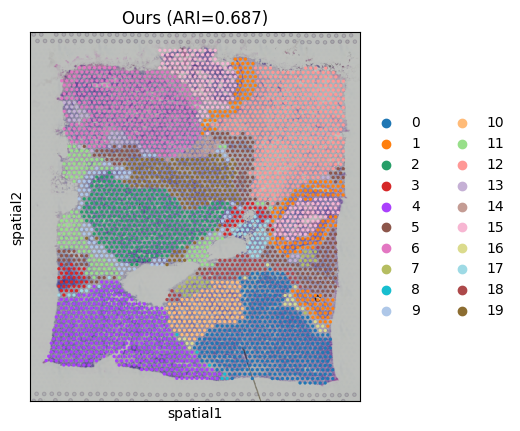

In [13]:
adata.obs["spCLUE"] = adata.obs["kmeans_refined"]
sc.pl.spatial(adata, color=[ "spCLUE"],show=False, title=[f"Ours (ARI={round(ARI_kmeans, 3)})"])
plt.savefig(f"{figures_dir}/HBC_spatial_6_11_radius10.png", bbox_inches='tight')
plt.show()
plt.close()

✅ UMAP saved to: figures_HBC/HBC_umap_fixed_6_11_radius10.png


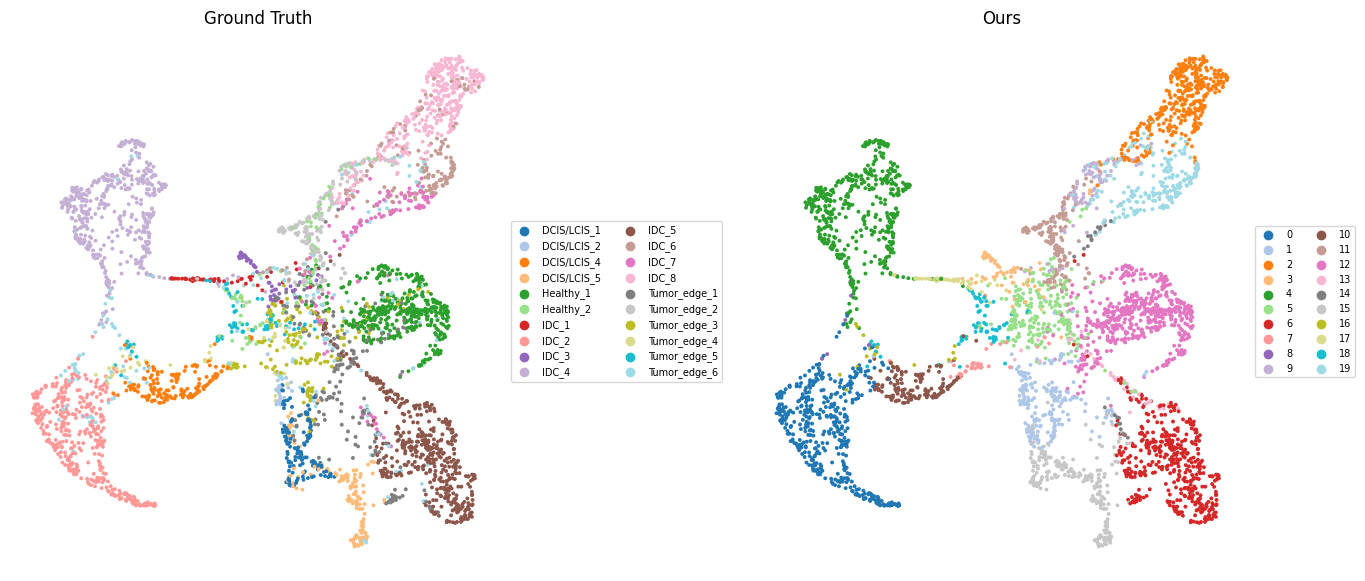

In [14]:
adata.obsm["embed"] = embed
sc.pp.neighbors(adata, n_neighbors=15, use_rep="embed")

# 计算 UMAP
sc.tl.umap(adata)

# # 绘图：同时查看 Ground Truth (Region) 和 你的聚类结果 (kmeans_refined)
# # 这样可以直观对比哪些区域分错了
# sc.pl.umap(adata, color=["Region", "kmeans_refined"], 
#            title=["Ground Truth", "Ours"],
#            show=False)

# # 保存图片
# plt.savefig(f"{figures_dir}/HBC_umap_6_11_fixed.png", bbox_inches='tight')
# plt.show()
# plt.close()
import matplotlib.pyplot as plt
import scanpy as sc

# 1. 增加画布宽度 (从默认大小改为 18x7)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 使用 20 类专用色板，防止颜色重复
cluster_palette = sc.pl.palettes.vega_20

# 2. 绘制第一个子图 (Ground Truth)
sc.pl.umap(
    adata, 
    color="Region", 
    title="Ground Truth",
    ax=axes[0], 
    show=False,
    palette=cluster_palette,
    frameon=False
)
# 强制将左侧图例改为 2 列并缩小字号
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=7)

# 3. 绘制第二个子图 (Ours)
sc.pl.umap(
    adata, 
    color="kmeans_refined", 
    title="Ours",
    ax=axes[1], 
    show=False,
    palette=cluster_palette,
    frameon=False
)
# 强制将右侧图例改为 2 列并缩小字号
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=7)

# 4. 调整子图间距，给右侧图例留出足够空间
plt.subplots_adjust(wspace=0.5) 

# 5. 先保存图片 (确保 bbox_inches='tight' 自动包含溢出的图例)
save_path = f"{figures_dir}/HBC_umap_fixed_6_11_radius10.png"
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"✅ UMAP saved to: {save_path}")

# 6. 后显示并关闭
plt.show()
plt.close()

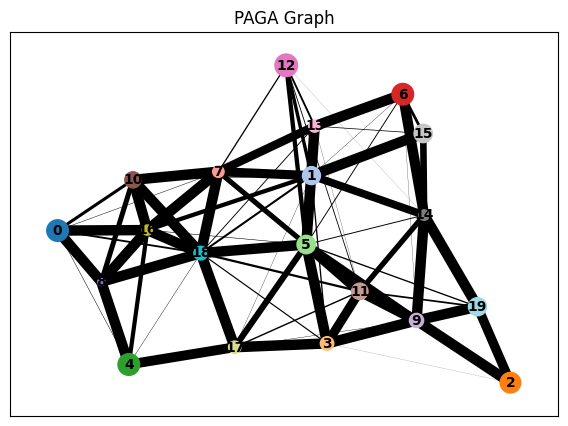

In [15]:
# 计算 PAGA
# groups 指定聚类结果所在的 obs 列名
sc.tl.paga(adata, groups="kmeans_refined")

# 绘图
# plot_threshold 可以控制显示连通性的阈值
sc.pl.paga(adata, color="kmeans_refined", 
           title=f"PAGA Graph",
           show=False)

# 保存图片
plt.savefig(f"{figures_dir}/HBC_paga_6_11_radius10.png", bbox_inches='tight')
plt.show()
plt.close()